In [15]:
import numpy as np
from modtran_analysis.tools import utils
from importlib import resources
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

LOCAL_DATA_PATH = resources.files("modtran_analysis") / "data"
#Here I just very quickly fixed things to try the v5 data, and renamed everything after this
DATA_FILE_PATH = LOCAL_DATA_PATH / "FV3_Modtran6_IO_v5_scene_88.nc"
ds_v5 = xr.open_dataset(DATA_FILE_PATH)
wavelength_v5_sw = ds_v5['wavelength_sw']
wavelength_v5_lw = ds_v5['wavelength_lw']
wavelength_v5_tot = utils.sw_lw_wavelength(wavelength_v5_sw, wavelength_v5_lw)

IGBP_Land_Type_v5 = ds_v5['IGBP_Type_FV3']
ERBE_RAA_v5 = ds_v5['ERBE_RAA']
ERBE_SZA_v5 = ds_v5['ERBE_SZA']
ERBE_VZA_v5 = ds_v5['ERBE_VZA']
ERBE_SW_RAD = utils.unit_conversion(ds_v5['MODTRAN6_SW_RAD_TOA_ERBE'], use_microwatts=False)
ERBE_LW_RAD = utils.unit_conversion(ds_v5['MODTRAN6_LW_RAD_TOA_ERBE'], use_microwatts=False)
ERBE_NIR_RAD = utils.unit_conversion(ds_v5['MODTRAN6_NIR_RAD_TOA_ERBE'], use_microwatts=False)
ERBE_VIS_RAD = utils.unit_conversion(ds_v5['MODTRAN6_VIS_RAD_TOA_ERBE'], use_microwatts=False)
ERBE_TOT_RAD = utils.unit_conversion(ds_v5['MODTRAN6_TOT_RAD_TOA_ERBE'], use_microwatts=False)
ERBE_SW_FLUX = utils.unit_conversion(ds_v5['MODTRAN6_SW_FLX_UPDIF_ERBE'], use_microwatts=False)
ERBE_LW_FLUX = utils.unit_conversion(ds_v5['MODTRAN6_LW_FLX_UPDIF_ERBE'], use_microwatts=False)
ERBE_NIR_FLUX = utils.unit_conversion(ds_v5['MODTRAN6_NIR_FLX_UPDIF_ERBE'], use_microwatts=False)
ERBE_VIS_FLUX = utils.unit_conversion(ds_v5['MODTRAN6_VIS_FLX_UPDIF_ERBE'], use_microwatts=False)
ERBE_TOT_FLUX = utils.unit_conversion(ds_v5['MODTRAN6_TOT_FLX_UPDIF_ERBE'], use_microwatts=False)

spectral_radiance_toa_sw_ERBE_v5 = ds_v5['MODTRAN6_SPECTRAL_RADIANCE_TOA_SW_WVL_ERBE']
spectral_radiance_toa_lw_ERBE_v5 = ds_v5['MODTRAN6_SPECTRAL_RADIANCE_TOA_LW_WVL_ERBE']

np.float64(5.163228020774699)

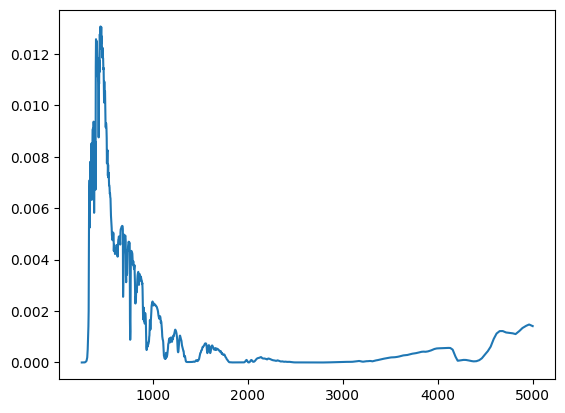

In [43]:
plt.plot(wavelength_v5_sw, utils.unit_conversion(spectral_radiance_toa_sw_ERBE_v5[1][1][1], use_microwatts=False))
utils.integrate_spectrum(wavelength_v5_sw[1:], utils.unit_conversion(spectral_radiance_toa_sw_ERBE_v5[1][1][1][1:], use_microwatts=False))



np.float64(35.193153588093274)

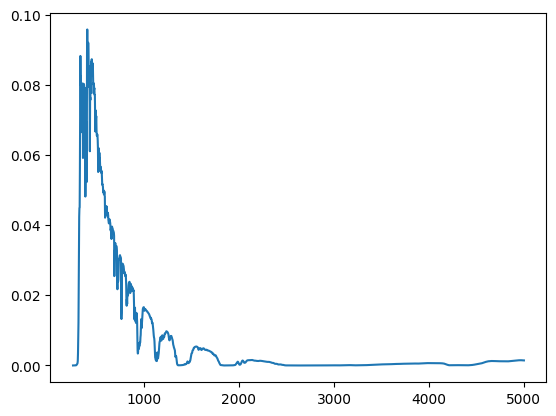

In [44]:
plt.plot(wavelength_v5_sw, utils.unit_conversion(spectral_radiance_toa_sw_ERBE_v5[0][0][0], use_microwatts=False))
utils.integrate_spectrum(wavelength_v5_sw[1:], utils.unit_conversion(spectral_radiance_toa_sw_ERBE_v5[0][0][0][1:], use_microwatts=False))



In [8]:
from libera_utils import scene_id
val_from_file = 17

# 1. Convert int to IGBPSurfaceType
# 2. Access the property
print(scene_id.IGBPSurfaceType(val_from_file).trmm_surface_type.name)

OCEAN


In [17]:
data_files = list(range(1, 129))-10
print(data_files)
# data_files[0]
# for data_file in data_files:
#     print(data_file)
#     print(data_files[data_file-1])
#     # print(data_files[data_file])

TypeError: unsupported operand type(s) for -: 'list' and 'int'

In [20]:

data_files = list(range(1, 129))
missing = [10, 11, 41, 54, 55, 56, 88, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122]
for i in range(len(missing)):
    data_files.remove(missing[i])
print(data_files)


[1, 2, 3, 4, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 123, 124, 125, 126, 127, 128]


In [9]:
import pandas as pd
import modtran_analysis.tools.utils as utils
df_func = pd.DataFrame(utils.table_output("v5/FV3_Modtran6_IO_v5_scene_1.nc", 'ERBE', 0, 0, 0, 0))

df_func['IGBP Scene']

0    OCEAN
Name: IGBP Scene, dtype: object

In [19]:
import numpy as np
data = [np.random.normal(0, std, 100) for std in range(1, 5)]
print(np.array(data))

[[ 5.87583597e-01  5.48431976e-02  2.80960443e+00  3.79313170e-01
   5.89842842e-01  6.80938588e-01 -9.56536418e-01 -5.51509451e-01
   8.00779009e-01 -7.36124242e-01 -9.20212606e-01  3.44296152e-02
   5.57783156e-01  2.64025197e+00  3.54943662e-01 -4.59342921e-02
  -1.51341071e+00 -7.48699246e-01 -4.76604133e-01 -5.67038551e-01
  -6.52513427e-01 -7.52910101e-01  9.43011638e-02  3.59901796e-01
  -7.47073149e-01  7.55126571e-01  8.63843853e-02  6.35002013e-01
  -1.11817474e-01  1.02511193e+00  1.46689921e+00 -4.24338526e-01
   8.15698640e-01 -6.99982127e-01 -1.56170326e-01 -1.27612189e+00
  -2.40749709e+00  1.01937677e+00  1.22091548e+00 -1.40871885e+00
   6.49469967e-01 -2.01748155e+00  5.46101945e-01 -1.77145119e+00
  -7.03537852e-01 -3.54916995e-01  1.78346065e+00 -4.33671750e-02
   2.48071652e-01 -1.80815669e+00 -2.31054591e+00 -2.41299688e-01
   4.78181570e-03 -8.17303585e-01  2.37742752e-01 -2.98871722e-01
  -1.35932184e-01  1.86937135e+00  6.09213128e-01  8.17591632e-01
  -6.06079

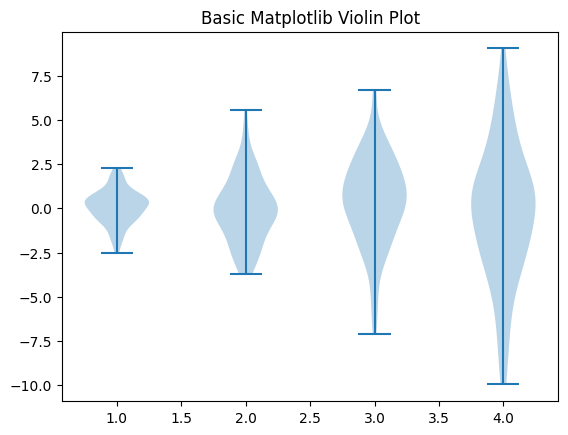

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Generate random data
data = [np.random.normal(0, std, 100) for std in range(1, 5)]

# Create the plot
plt.violinplot(data)
plt.title('Basic Matplotlib Violin Plot')
plt.show()



In [11]:
import modtran_analysis.tools.utils as utils
import pandas as pd

for s in list(range(10)):
    for r in list(range(8)):
        for v in list(range(7)):
            df = utils.table_output('v5/FV3_Modtran6_IO_v5_scene_2.nc', 'ERBE', r, s, v, 0)
pd.DataFrame(df)




TypeError: cannot concatenate object of type '<class 'list'>'; only Series and DataFrame objs are valid

In [5]:
list(range(10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [1]:
import modtran_analysis.tools.utils as utils
all_results = []

for s in list(range(10)):
    for r in list(range(8)):
        for v in list(range(7)):
            df = utils.table_output('v5/FV3_Modtran6_IO_v5_scene_2.nc', 'ERBE', r, s, v, 0)
            all_results.append(df)

import pandas as pd
utils.table_summary('v5/FV3_Modtran6_IO_v5_scene_2.nc', all_results)

<built-in method replace of str object at 0x164a33b40>


KeyError: 'lat(deg)'

In [13]:
print(pd.DataFrame(all_results))
print(all_results[0].get('IGBP Scene'))

    ADM-Type     VZA      RAA     SZA IGBP Scene SW Radiance  \
0     [ERBE]   [7.5]    [4.5]  [12.9]    [OCEAN]    [49.182]   
1     [ERBE]  [21.0]    [4.5]  [12.9]    [OCEAN]    [48.525]   
2     [ERBE]  [33.0]    [4.5]  [12.9]    [OCEAN]    [39.171]   
3     [ERBE]  [45.0]    [4.5]  [12.9]    [OCEAN]    [33.027]   
4     [ERBE]  [57.0]    [4.5]  [12.9]    [OCEAN]    [35.388]   
..       ...     ...      ...     ...        ...         ...   
555   [ERBE]  [33.0]  [175.5]  [87.1]    [OCEAN]     [5.620]   
556   [ERBE]  [45.0]  [175.5]  [87.1]    [OCEAN]     [6.786]   
557   [ERBE]  [57.0]  [175.5]  [87.1]    [OCEAN]     [8.446]   
558   [ERBE]  [69.0]  [175.5]  [87.1]    [OCEAN]    [11.203]   
559   [ERBE]  [82.5]  [175.5]  [87.1]    [OCEAN]    [15.142]   

    INTEGRATED SW Radiance NIR Radiance INTEGRATED NIR Radiance LW Radiance  \
0                 [49.231]     [20.064]                [20.076]   [105.616]   
1                 [48.571]     [20.033]                [20.045]   [104.92

In [18]:
table = pd.DataFrame(all_results)
table['IGBP Scene']

0      [OCEAN]
1      [OCEAN]
2      [OCEAN]
3      [OCEAN]
4      [OCEAN]
        ...   
555    [OCEAN]
556    [OCEAN]
557    [OCEAN]
558    [OCEAN]
559    [OCEAN]
Name: IGBP Scene, Length: 560, dtype: object

In [2]:
utils.table_summary('v5/FV3_Modtran6_IO_v5_scene_2.nc', all_results)


KeyError: 'ADM Type'

In [22]:
utils.table_summary('v5/FV3_Modtran6_IO_v5_scene_2.nc', all_results)


TypeError: list indices must be integers or slices, not str

In [2]:
filename = 'v5/FV3_Modtran6_IO_v5_scene_2.nc'
import modtran_analysis.tools.utils as utils
all_results = []

for s in list(range(10)):
    for r in list(range(8)):
        for v in list(range(7)):
            df = utils.table_output('v5/FV3_Modtran6_IO_v5_scene_2.nc', 'ERBE', r, s, v, 0)
            all_results.append(df)
table = all_results

In [7]:
from importlib import resources
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
LOCAL_DATA_PATH = resources.files("modtran_analysis") / "data"
DATA_FILE_PATH = LOCAL_DATA_PATH / filename
ds = xr.open_dataset(DATA_FILE_PATH)
scene_data = LOCAL_DATA_PATH / 'fv3_subset_for_ceres-trmm_erbe_scenes.txt'
scene_data = pd.read_csv(scene_data, sep=',')
filename_index = int(str(filename)[28:-3]) #based off the naming convention of "FV3_Modtran6_IO_v5_scene_1.nc"

# scene 1 (data name) = row 1 of the scene data file *supposedly*, we are checking that here
table = pd.DataFrame(table)
surface_type = table['IGBP Scene']
ADM_type = table['ADM-Type']
total_radiance_max_calculated = np.max(np.array(table['Tot Radiance']))
total_radiance_max_integrated = np.max(table['INTEGRATED TOT Radiance'])
total_flux_max_calculated = np.max(table['Tot Flux'])
total_flux_max_integrated = np.max(table['INTEGRATED TOT Flux']) #this we still have a problem with because of the passthrough of the flux values
total_radiance_min_calculated = np.min(table['Tot Radiance'])
total_flux_min_integrated = np.min(table['INTEGRATED TOT Flux']) #this we still have a problem with because of the passthrough of the flux values
df = pd.DataFrame(table)
print(scene_data[' lat(deg)'][88])
    # Remove the extension and "Final"
title = filename.replace(".nc", "").replace
print(title)  # Output: 2023 Financial Report
with open(f"data-summary-'{filename[3:]}'", "w") as f:
    f.write(F'''DATA SUMMARY OF DATA FILE {filename}
latitude/longitude of file = {ds['FV3_lat'].values}{ds['FV3_lat'].units}, {ds['FV3_lon'].values}{ds['FV3_lon'].units}
compared lat/lon = {scene_data[' lat(deg)'][int(filename_index)]} Degrees, {scene_data[' lon(deg)'][filename_index]} Degrees
ADM Type = {ADM_type}

''')

print(f'MAX total radiance = {total_radiance_max_calculated} at {np.where(total_radiance_max_calculated)}')
print(table['Tot Radiance'].max())

# 1. Clean the data (convert the 'weird' strings to NaN so they don't break math)
df['Tot Radiance'] = pd.to_numeric(df['Tot Radiance'], errors='coerce')
df['Tot Flux'] = pd.to_numeric(df['Tot Flux'], errors='coerce')

    # 2. Find the index of the maximum value
max_rad_idx = df['Tot Radiance'].idxmax()
max_flux_idx = df['Tot Flux'].idxmax()

    # 3. Extract the geometry for those maximums
max_rad_val = df.loc[max_rad_idx, 'Tot Radiance']
max_rad_vza = df.loc[max_rad_idx, 'VZA']
max_rad_sza = df.loc[max_rad_idx, 'SZA']
max_rad_raa = df.loc[max_rad_idx, 'RAA']
max_idx = table['Tot Radiance'].idxmax()
max_val = table.loc[max_idx, 'Tot Radiance']
print(f"MAX total radiance = {max_rad_val:.3f}")
print(f"Occurs at: VZA={max_rad_vza}, SZA={max_rad_sza}, RAA={max_rad_raa}")

    # Check for the 'weird' flux values
if df['INTEGRATED TOT Flux'].dtype == 'object':
    print("WARNING: INTEGRATED TOT Flux contains non-numeric/overflow values.")

-22.25
<built-in method replace of str object at 0x13f5901c0>
MAX total radiance = ['90.006'] at (array([0]),)
['90.006']


/var/folders/q3/1_r176sd70756jdzymxr5d5m00cbpp/T/ipykernel_11883/2870165440.py:44: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max_rad_idx = df['Tot Radiance'].idxmax()
/var/folders/q3/1_r176sd70756jdzymxr5d5m00cbpp/T/ipykernel_11883/2870165440.py:45: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max_flux_idx = df['Tot Flux'].idxmax()


KeyError: nan

In [47]:
max_rad_idx = table['Tot Radiance'].idxmax()
print(max_rad_idx)

538


In [48]:
total_radiance_max = table['Tot Radiance'].max()
print(total_radiance_max)

['90.006']


In [49]:
true_max = ds['Tot Radiance'].max().values
print(f"True Global Max: {true_max}")

KeyError: "No variable named 'Tot Radiance'. Variables on the dataset include ['ERBE_RAA', 'ERBE_SZA', 'ERBE_VZA', 'CERES_TRMM_RAA', 'CERES_TRMM_SZA', ..., 'MODTRAN6_550NM_RAD_TOA_CERES-TRMM', 'MODTRAN6_550NM_DNFLX_TOA_CERES-TRMM', 'wavelength_sw', 'wavelength_lw', 'wavenumber']"

In [11]:
def table_summary(filename, table):
    import pandas as pd
    import numpy as np

    # 1. Convert to DataFrame
    df = pd.DataFrame(table)

    # 2. Convert to numeric (crucial if they are strings)
    df['Tot Radiance'] = pd.to_numeric(df['Tot Radiance'], errors='coerce')

    # 3. Check if the column is empty or all NaNs
    # This prevents the FutureWarning and the KeyError
    if df['Tot Radiance'].isna().all():
        print(f"Skipping {filename}: No valid numeric data found in 'Tot Radiance'.")
        return

    # 4. Now it is safe to call idxmax()
    max_rad_idx = df['Tot Radiance'].idxmax()

    # Double check it's not a single NaN (extra safety)
    if pd.isna(max_rad_idx):
        return

    max_rad_row = df.loc[max_rad_idx]

    # ... rest of your code ...
    print(f"Max Radiance found: {max_rad_row['Tot Radiance']}")

In [12]:
table_summary(filename, table)

Skipping v5/FV3_Modtran6_IO_v5_scene_2.nc: No valid numeric data found in 'Tot Radiance'.


In [18]:
filename = 'v5/FV3_Modtran6_IO_v5_scene_2.nc'
import modtran_analysis.tools.utils as utils
all_results = []

for s in list(range(10)):
    for r in list(range(8)):
        for v in list(range(7)):
            df = utils.table_output('v5/FV3_Modtran6_IO_v5_scene_2.nc', 'ERBE', r, s, v, 0)
            all_results.append(df)
table = pd.DataFrame(all_results)

In [24]:
print(table.columns)

Index(['ADM-Type', 'VZA', 'RAA', 'SZA', 'IGBP Scene', 'SW Radiance',
       'INTEGRATED SW Radiance', 'NIR Radiance', 'INTEGRATED NIR Radiance',
       'LW Radiance', 'INTEGRATED LW Radiance', 'VIS Radiance',
       'INTEGRATED VIS Radiance', 'Tot Radiance', 'INTEGRATED TOT Radiance',
       'SW Flux', 'INTEGRATED SW Flux', 'NIR Flux', 'INTEGRATED NIR Flux',
       'LW Flux', 'INTEGRATED LW Flux', 'VIS Flux', 'INTEGRATED VIS Flux',
       'Tot Flux', 'INTEGRATED TOT Flux'],
      dtype='object')


In [26]:
print(table['Tot Radiance'].idxmax())

538


In [27]:
# 1. Find the index (the row label)
max_index = table['Tot Radiance'].idxmax()

# 2. Use that index to see the full row of data
print(f"Maximum radiance is at index: {max_index}")
print(table.loc[max_index])

Maximum radiance is at index: 538
ADM-Type                                                              [ERBE]
VZA                                                                   [82.5]
RAA                                                                  [105.0]
SZA                                                                   [87.1]
IGBP Scene                                                           [OCEAN]
SW Radiance                                                         [19.054]
INTEGRATED SW Radiance                                              [19.061]
NIR Radiance                                                         [7.116]
INTEGRATED NIR Radiance                                              [7.121]
LW Radiance                                                         [70.953]
INTEGRATED LW Radiance                                              [70.665]
VIS Radiance                                                        [11.937]
INTEGRATED VIS Radiance                   